<a href="https://colab.research.google.com/github/stephenfrein/vucsc8491/blob/main/Week5_Linear_and_Logistic_Regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<a href="https://colab.research.google.com/github/stephenfrein/vucsc8491/blob/main/Week5_Linear_and_Logistic_Regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


# Week 5: Linear and Logistic Regression

Last week we covered **unsupervised** techniques (clustering and association rules), where we didn't have a labeled historical outcome to predict. This week we'll focus **supervised** learning, where we have historical examples with a known outcome (ground truth) and we want to learn the relationship between our predictors and that outcome.

We'll cover two of the most fundamental supervised techniques:

* **Linear regression**: predicting a *continuous* numeric outcome (e.g., life expectancy, price, temperature)
* **Logistic regression**: predicting a *categorical* outcome, usually binary (e.g., loan will or won't go into default, customer will or won't leave us)

Logistic regression is a **classification** technique, not a regression technique. It does predict a number, but that number is the probability of something beloging to a certain class.


## Linear Regression Refresher

We got a preview of linear regression back in Week 3 when we looked at the Curse of Dimensionality. Now let's dive in deeper.

Simple linear regression (one predictor) fits a straight line through a cloud of points:

**y = b&#8320; + b&#8321;x**

* **b&#8320;** (the intercept) is the predicted value of y when x is 0
* **b&#8321;** (the slope) is how much y changes for every 1-unit increase in x
* the **residual** for a given point is the difference between its actual y value and the y value the line predicts

The "best fit" line is the one that minimizes the sum of the squared residuals across all the data points - this is why the technique is sometimes called **ordinary least squares (OLS)**.


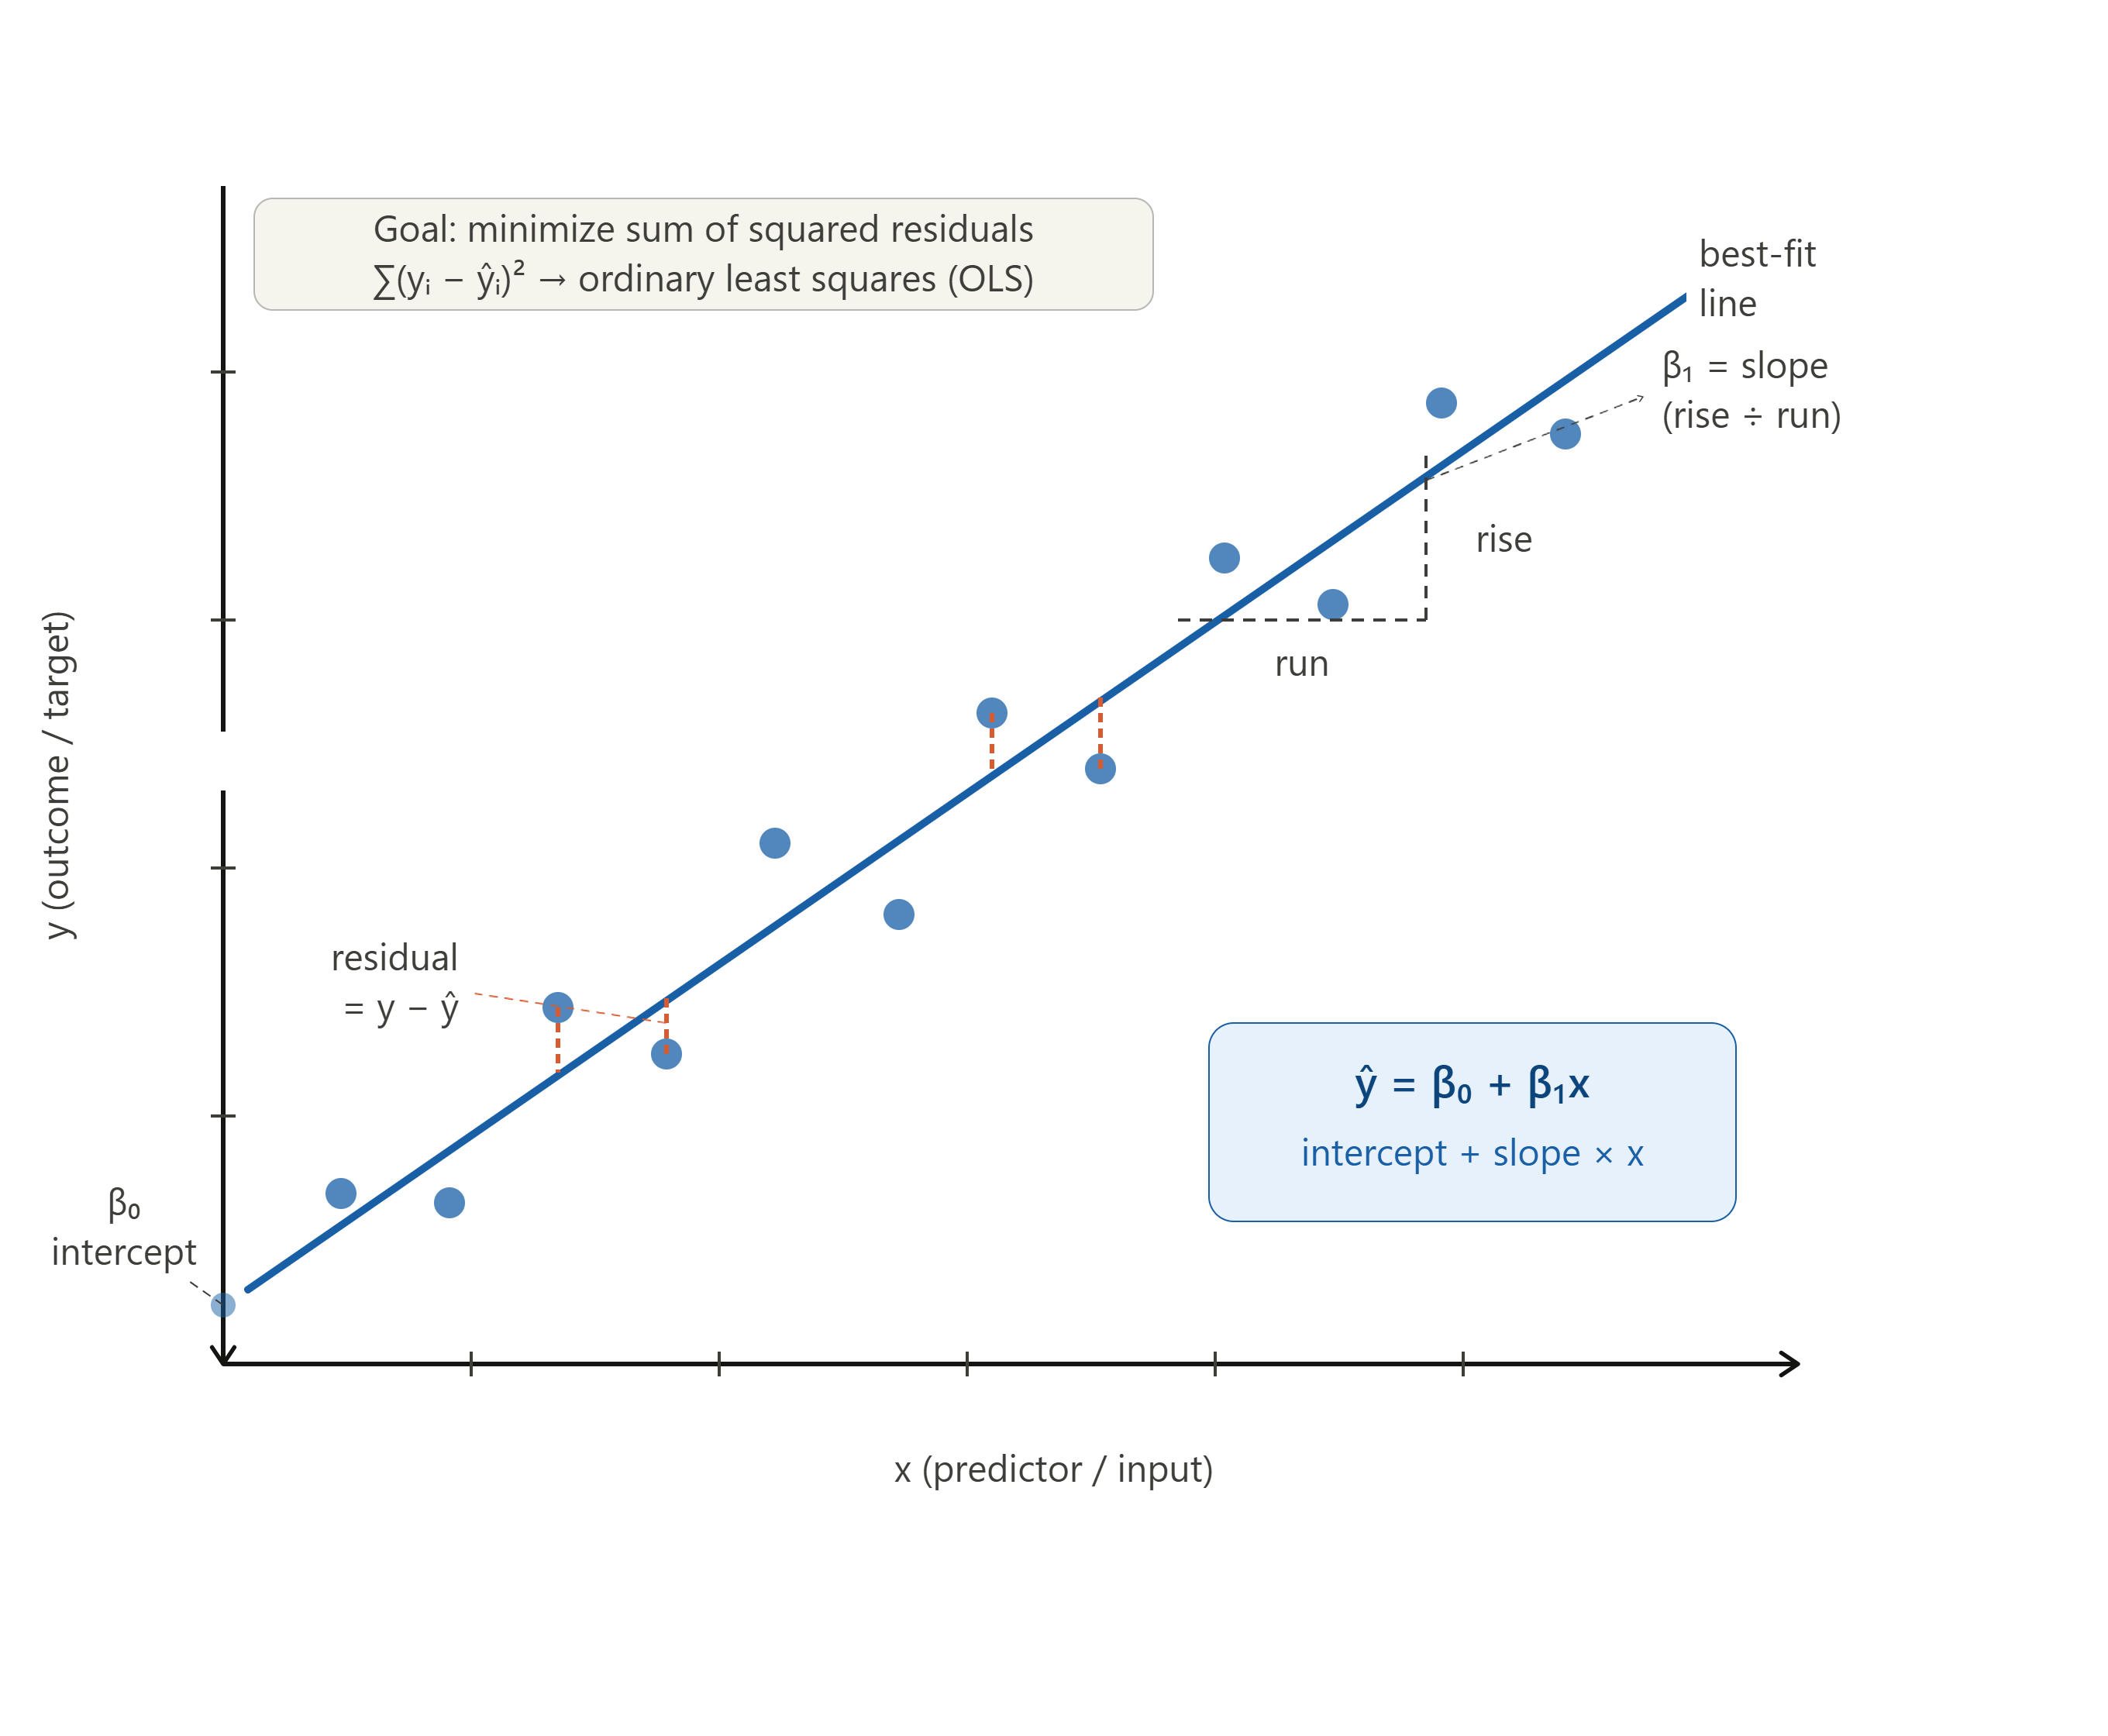

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

# number of points we'll create
n = 50

# create x values and an underlying relationship of y = 4x + 10, plus some noise
# no seed is set here on purpose
x = np.random.uniform(0, 10, n)
y = 4 * x + 10 + np.random.normal(0, 5, n)

# reshape x into a 2D array - scikit-learn expects a 2D array of predictors
# -1 means "figure out how many I need" and 1 means "1 column" (check docs for detail)
X = x.reshape(-1, 1)

# fit the model
lr = LinearRegression()
lr.fit(X, y)

# the fitted intercept and slope
print('Formula is: y = ' + str(lr.intercept_) + ' + ' + str(lr.coef_[0]) + 'x')

# plot the data points and the fitted line
plt.figure(figsize=(7, 5))
plt.scatter(x, y, label='actual data')
plt.plot(x, lr.predict(X), linewidth=2, color='orange', label='fitted line')
plt.xlabel('x')
plt.ylabel('y')
plt.title('Simple Linear Regression')
plt.legend()
plt.show()


**Discuss...**

Run the above multiple times - what do you observe?

What is the cause of that?

## More Detail with statsmodel

Folks coming from an R background can't get the delicious summary() they crave from basic scikit-learn. We'll use statsmodel to get some extra detail about our model, including statistical significance.

We're going to regenerate the data deterministically (setting seed value) so we can interpret the output more rigorously.

In [ ]:
import statsmodels.api as sm

n = 100

# make our results repeatable
np.random.seed(123)

# same logic we used before to build data
x = np.random.uniform(0, 10, n)
y = 4 * x + 10 + np.random.normal(0, 5, n)

# reshape as column
X = x.reshape(-1, 1)

# statsmodels requires you to add an intercept column
X_with_constant = sm.add_constant(X)

print('X before adding constant:')
display(X[:5])

print('X after adding constant:')
display(X_with_constant[:5])

# fit model and print the summary
print('\nModel summary:')
model = sm.OLS(y, X_with_constant).fit()
print(model.summary())

print('\np-values:')
print(model.pvalues)


**Interpreting Results**

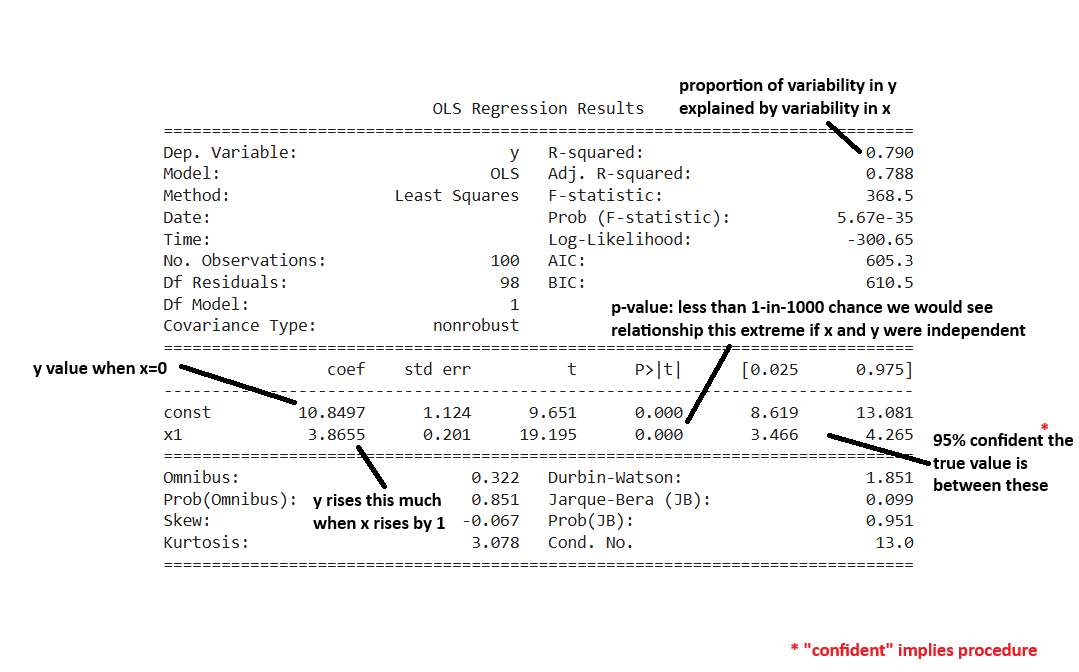

**Consider...**

If the bottom of the confidence interval for x1 were -1.432, what might we conclude about the relationship between x and y?

## Stats Refresher: The Normal Distribution

The normal distribution is a bell-shaped curve often assumed by naturally occurring data (e.g., height, weight).

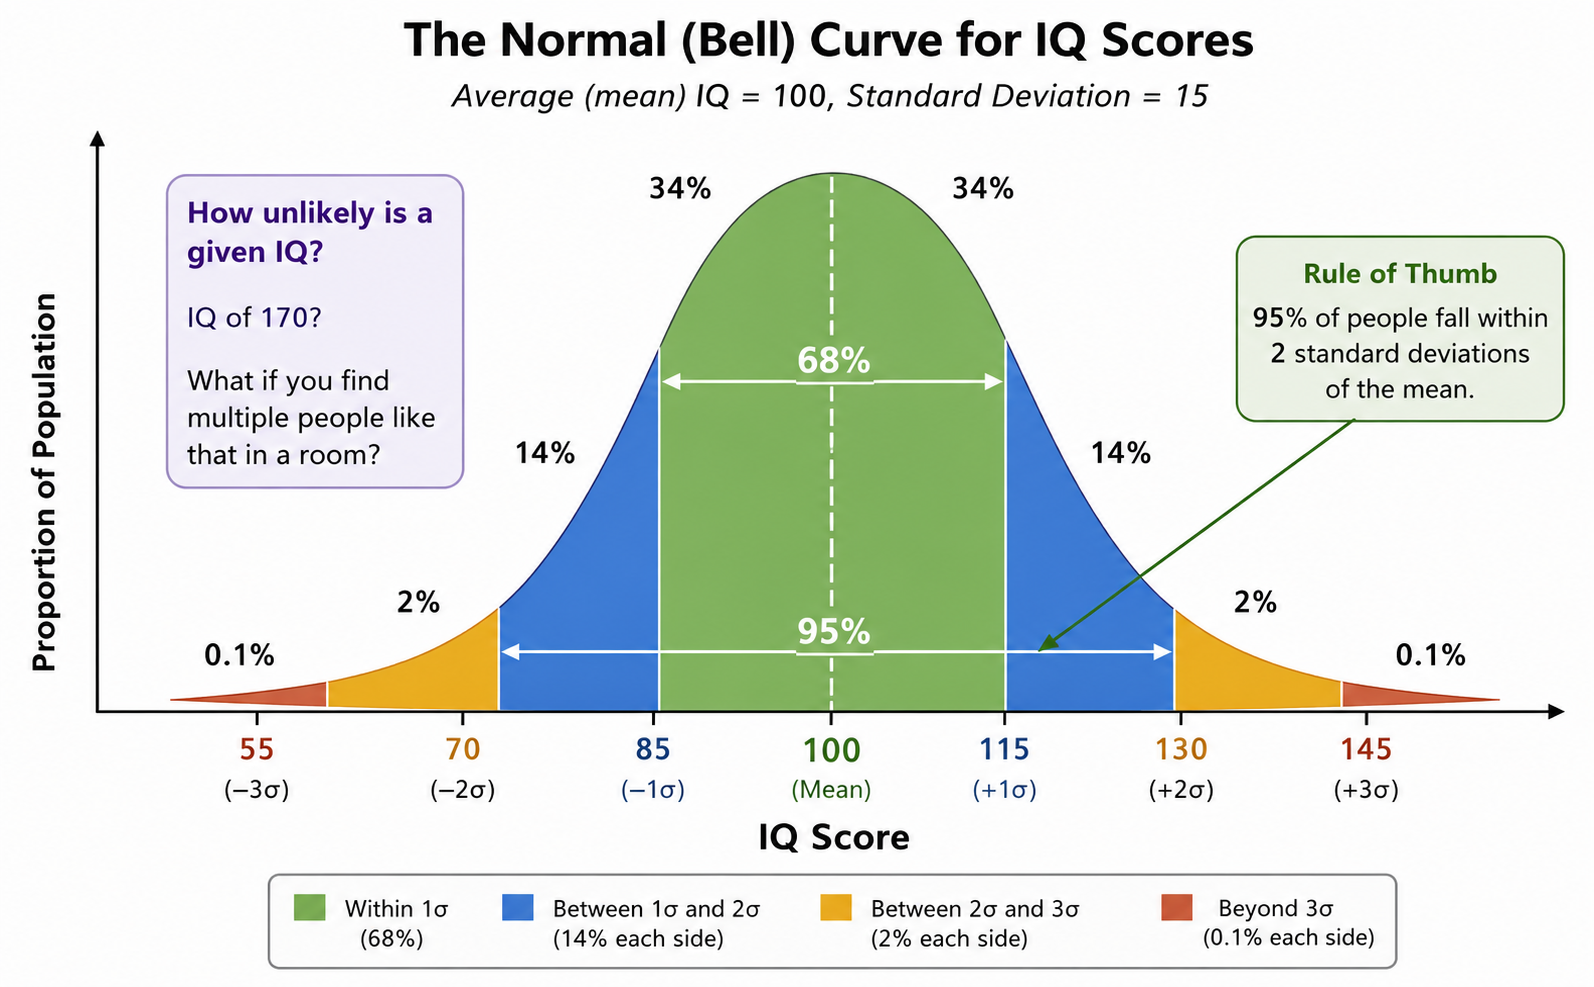

Der

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

# set up variables
# size of population
pop_size = 20000

# size of samples
samp_sz = 40

# how many samples will we take?
num_samples = 2000

# target mean value of generated population data
mean_val = 25000

# target standard deviation of generated population data
standard_dev = 5000

# set a seed so results are reproducible
np.random.seed(123)

In [ ]:
# create normal distribution
pop_norm = np.random.normal(
    loc=mean_val,
    scale=standard_dev,
    size=pop_size
)

print("mean of normal population:", np.mean(pop_norm))
print("standard deviation of normal population:", np.std(pop_norm, ddof=1))


# view the shape
plt.figure(figsize=(8, 5))
plt.hist(pop_norm, bins=140, density=True, alpha=0.6)
plt.title("Normal Population")
plt.xlabel("Value")
plt.ylabel("Density")
plt.show()

In [ ]:
# now create skewed distribution by shrinking a random half of the values
# then shift the whole population so it has the same mean as the normal population.
pop_skewed = pop_norm.copy()

samp_skewed = np.random.choice(
    pop_size,
    size=int(pop_size * 0.5),
    replace=False
)

pop_skewed[samp_skewed] = pop_skewed[samp_skewed] * 0.67


# give it same center as the normal distribution
print("mean of skewed population before recentering:", np.mean(pop_skewed))

pop_skewed = pop_skewed + (np.mean(pop_norm) - np.mean(pop_skewed))

print("mean of skewed population after recentering:", np.mean(pop_skewed))
print("standard deviation of skewed population:", np.std(pop_skewed, ddof=1))


# now look at the shape
plt.figure(figsize=(8, 5))
plt.hist(pop_skewed, bins=140, density=True, alpha=0.6)
plt.title("Skewed Population")
plt.xlabel("Value")
plt.ylabel("Density")
plt.show()

In [ ]:
pops = {
    "normal": pop_norm,
    "skewed": pop_skewed
}

saved_means_for_distros = {}

# iterate over the populations
for pop_name, pop_values in pops.items():

    print(f"\n*** {pop_name} ***")

    means = []   # vector of means for the population samples
    est_se = []  # vector of estimated standard errors

    for j in range(num_samples):

        # take a random sample from the population
        samp = np.random.choice(
            len(pop_values),
            size=samp_sz,
            replace=False
        )

        sample_values = pop_values[samp]

        # calculate the mean of that sample
        means.append(np.mean(sample_values))

        # estimate the standard error using sd / sqrt(n)
        # ddof=1 applies Bessel's correction (n-1)
        est_se.append(np.std(sample_values, ddof=1) / np.sqrt(samp_sz))

    means = np.array(means)
    est_se = np.array(est_se)

    saved_means_for_distros[pop_name] = means

    population_mean = np.mean(pop_values)

    # plot distribution of the sample means for the distro
    plt.figure(figsize=(8, 5))

    plt.hist(
        means,
        bins=40,
        density=True,
        alpha=0.6,
        label="Sample means"
    )

    x_vals = np.linspace(means.min(), means.max(), 500)

    plt.plot(
        x_vals,
        norm.pdf(
            x_vals,
            loc=np.mean(means),
            scale=np.std(means, ddof=1)
        ),
        linewidth=2,
        label="Normal curve using mean and sd of sample means"
    )

    plt.axvline(
        population_mean,
        linestyle="--",
        linewidth=2,
        label="Actual population mean"
    )

    plt.title(f"{pop_name.capitalize()} Population: Distribution of Sample Means")
    plt.xlabel("Sample Mean")
    plt.ylabel("Density")
    plt.legend()
    plt.show()

    # print out the mean of the sample means
    print("Mean of population:", population_mean)
    print("Mean of sample means:", np.mean(means))
    print("Standard deviation of sample means:", np.std(means, ddof=1))

    print(
        "The mean of sample means is "
        f"{abs(np.mean(means) - population_mean)} "
        f"({abs((np.mean(means) - population_mean) / population_mean) * 100}%) "
        "off the actual population mean"
    )

    print(
        "The average estimate of the standard error of the mean using sd/sqrt(n) is "
        f"{np.mean(est_se)}"
    )

    print(
        "This average estimate is within "
        f"{abs(np.mean(est_se) - np.std(means, ddof=1)) / np.std(means, ddof=1) * 100}% "
        "of the standard deviation of the sample means"
    )

## Real Scenario: Predicting Life Expectancy

We'll return to the WHO Life Expectancy data set. The columns in the raw CSV have some messy extra whitespace in their names (a good reminder from Week 1 that real data is rarely clean out of the box), so we'll strip those first.

We'll start with a **single predictor**: years of schooling. Does more schooling in a country associate with a longer life expectancy?


In [ ]:
import pandas as pd

life_df = pd.read_csv('https://raw.githubusercontent.com/stephenfrein/vucsc8491/refs/heads/main/LifeExpectancyData.csv')

# strip stray whitespace from column names
life_df.columns = life_df.columns.str.strip()

# drop rows that are missing our columns of interest
life_df = life_df.dropna(subset=['Life expectancy', 'Schooling'])

display(life_df[['Country', 'Year', 'Life expectancy', 'Schooling']].head())


In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
import matplotlib.pyplot as plt

X = life_df[['Schooling']]
y = life_df['Life expectancy']

lr_schooling = LinearRegression()
lr_schooling.fit(X, y)

print('Intercept: ' + str(lr_schooling.intercept_))
print('Slope: ' + str(lr_schooling.coef_[0]))
print('R-squared: ' + str(r2_score(y, lr_schooling.predict(X))))

# each additional year of schooling is associated with this many more years of life expectancy
plt.figure(figsize=(7, 5))
plt.scatter(life_df['Schooling'], y, alpha=0.3, color='#4C72B0')
plt.plot(life_df['Schooling'], lr_schooling.predict(X), color='#DD8452', linewidth=3)
plt.xlabel('Schooling (years)')
plt.ylabel('Life Expectancy')
plt.title('Life Expectancy vs. Schooling')
plt.show()


**Interpreting the slope**: the slope tells us that, on average, each additional year of schooling is associated with an increase in life expectancy of about that many years. This is a **correlation**, not necessarily **causation** - countries with more schooling likely differ in many other ways too (income, healthcare access, etc.) that we haven't accounted for yet.

R-squared tells us what proportion of the variation in life expectancy is "explained" by schooling alone.


## Exercise 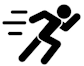

Try fitting a simple linear regression using a different single predictor from the data set (for example, `GDP`, `Alcohol`, or `Adult Mortality` instead of `Schooling`). How does the R-squared compare? Does the direction of the slope (positive or negative) make sense to you?


## Multiple Linear Regression

A single predictor rarely tells the whole story. **Multiple linear regression** extends the same idea to several predictors at once:

**y = b&#8320; + b&#8321;x&#8321; + b&#8322;x&#8322; + ... + b&#8345;x&#8345;**

Each coefficient (b&#8321;, b&#8322;, ...) tells us the effect of that predictor **holding all the other predictors constant**. We can't easily draw this on a 2D chart anymore once we have more than one or two predictors, but the fitting process (minimizing squared residuals) works the same way.


In [ ]:
from sklearn.model_selection import train_test_split

# a handful of numeric predictors to work with
predictor_cols = ['Adult Mortality', 'BMI', 'GDP', 'Schooling', 'Alcohol']

life_multi_df = life_df.dropna(subset=predictor_cols + ['Life expectancy'])

X_multi = life_multi_df[predictor_cols]
y_multi = life_multi_df['Life expectancy']

# split into training and test sets, just like we did in Week 3
X_train, X_test, y_train, y_test = train_test_split(X_multi, y_multi, test_size=0.2, random_state=123)

lr_multi = LinearRegression()
lr_multi.fit(X_train, y_train)

# pair each predictor name with its coefficient so we can read the results
for name, coef in zip(predictor_cols, lr_multi.coef_):
    print(name + ': ' + str(coef))

print('\nIntercept: ' + str(lr_multi.intercept_))
print('R-squared on test data: ' + str(r2_score(y_test, lr_multi.predict(X_test))))


## Exercise 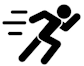

Add one or two more numeric columns to `predictor_cols` (or remove one) and re-run the cell above. Does the test R-squared improve? Do any of the coefficients change sign or magnitude in a surprising way when other predictors are added?


## From Continuous to Categorical: The Problem with Using Linear Regression for Classification

So far, our outcome variable has always been a number that can take on a wide range of continuous values. What if, instead, our outcome is categorical - something like whether a passenger survived the Titanic (yes/no), whether a customer will churn (yes/no), or which of several product categories a transaction belongs to?

You might be tempted to just code "yes" as 1 and "no" as 0 and run an ordinary linear regression. The problem is that a straight line has no natural floor or ceiling - it can predict values well below 0 or well above 1, which don't make sense as probabilities.


logistic_vs_linear_explainer.svg


## The Logistic Function

Logistic regression solves this problem by squashing the output of a linear combination of predictors through the **logistic (sigmoid) function**, which always produces a value between 0 and 1:

**p(y=1) = 1 / (1 + e<sup>-(b&#8320; + b&#8321;x)</sup>)**

A few important related concepts:

* **Probability**: the sigmoid output itself, always between 0 and 1
* **Odds**: probability of the event divided by probability it doesn't happen - *odds = p / (1-p)*
* **Log-odds (logit)**: the natural log of the odds - this is actually what the linear part of the model (b&#8320; + b&#8321;x) is directly predicting
* **Decision threshold**: the probability cutoff (0.5 by default) above which we classify a case as "yes"

A useful way to interpret a logistic regression coefficient: **e<sup>b</sup>** (e raised to the coefficient) gives you the **odds ratio** - how much the odds of the outcome multiply for each 1-unit increase in that predictor.


## Real Scenario: Predicting Titanic Survival

We've used the Titanic data set before for exploration and visualization. Now let's actually build a model to predict who survived, based on passenger class, sex, age, and fare.

Logistic regression requires numeric inputs, so we'll need to convert `Sex` into a 0/1 column first.


In [ ]:
import pandas as pd

titanic_df = pd.read_csv('https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv')

# logistic regression needs numeric predictors - convert Sex into a 0/1 column
titanic_df['Sex_numeric'] = (titanic_df['Sex'] == 'female').astype(int)

# Age has some missing values - fill with the median as a simple approach
titanic_df['Age'] = titanic_df['Age'].fillna(titanic_df['Age'].median())

feature_cols = ['Pclass', 'Sex_numeric', 'Age', 'Fare']

display(titanic_df[feature_cols + ['Survived']].head())


**??? Before running the next cell, what do you expect: will `Sex_numeric` end up with a positive or negative coefficient? What about `Pclass`? ???**


In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
import numpy as np

X = titanic_df[feature_cols]
y = titanic_df['Survived']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=123)

log_reg = LogisticRegression(max_iter=1000)
log_reg.fit(X_train, y_train)

y_pred = log_reg.predict(X_test)

print('Accuracy on test data: ' + str(accuracy_score(y_test, y_pred)))

# pair up each feature with its coefficient and odds ratio
print('\nFeature       Coefficient   Odds Ratio')
for name, coef in zip(feature_cols, log_reg.coef_[0]):
    print(name + ': ' + str(coef) + '  (odds ratio ' + str(np.exp(coef)) + ')')


**Interpreting the odds ratios**: an odds ratio greater than 1 means the predictor is associated with *higher* odds of survival as it increases; an odds ratio less than 1 means *lower* odds. For `Sex_numeric`, an odds ratio well above 1 reflects the famous "women and children first" pattern - being female was strongly associated with higher survival odds on the Titanic.


## Evaluating Classification Models

Accuracy alone doesn't tell the whole story, especially when the two outcome classes aren't evenly balanced. The **confusion matrix** breaks predictions down by what actually happened versus what the model predicted, and gives us the building blocks for several other metrics.


confusion_matrix_explainer.svg


In [ ]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted: No', 'Predicted: Yes'],
            yticklabels=['Actual: No', 'Actual: Yes'])
plt.title('Titanic Survival - Confusion Matrix')
plt.show()

print(classification_report(y_test, y_pred, target_names=['Did not survive', 'Survived']))


## Exercise 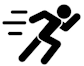

Try adding `SibSp` (number of siblings/spouses aboard) to `feature_cols` and re-fit the logistic regression model. Does accuracy improve? Look at the precision and recall for the "Survived" class specifically - did they move in the same direction?


## Linear vs. Logistic - When to Use Which

| | Linear Regression | Logistic Regression |
|---|---|---|
| Outcome type | continuous number | categorical (often binary) |
| Output | predicted value | predicted probability (0-1) |
| Fitting method | minimize sum of squared residuals | maximize likelihood of observed outcomes |
| Coefficient meaning | change in y per unit of x | change in log-odds per unit of x |
| Common evaluation metric | R-squared | accuracy, precision, recall, confusion matrix |

Both are considered simple, highly interpretable models - a good reason they're often used as a baseline before trying more complex approaches like tree-based models or neural networks, which we'll get to in the coming weeks.
